# PROJECT: FAKE NEWS DETECTION SYSTEM
#### TASK: DATA COLLECTION, LABELING & INTEGRATION


In [ ]:
load_dotenv()

## 1. Importing Libraries for Data Handling

In [ ]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# Tools for future modeling (Keep for team consistency)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

## -----------------------------------------------------------------
## 2. DATA COLLECTION (Loading Raw Datasets)

In [ ]:
# Loading the fake news dataset from a compressed CSV file
df_fake =pd.read_csv("Fake.csv")
# Loading the true news dataset from a compressed CSV file
df_true = pd.read_csv("True.csv")

In [ ]:
# Displaying the first few rows
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


#### Visualizing the initial collection size

In [ ]:
# Checking the number of rows and columns (shape) for both datasets
df_fake.shape,df_true.shape

((23481, 4), (21417, 4))

## -----------------------------------------------------------------
## 3. DATA LABELING (Assigning Categories)

In [ ]:
# Assigning a target value of 0 to all rows in the fake news dataset
df_fake['target']= 0
# Assigning a target value of 1 to all rows in the true news dataset
df_true['target'] = 1

## -----------------------------------------------------------------
## 4. DATA INTEGRATION (Merging & Randomization)


In [ ]:
# Merge (Concatenate)
df=pd.concat([df_fake,df_true])

# Shuffling
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,title,text,subject,date,target
0,"Defying Trump, Twitter feeds for U.S. governme...",(Reuters) - Rogue Twitter feeds voicing employ...,politicsNews,"January 26, 2017",1
1,GLOBAL CLIMATE CHANGE LIARS Ignore Truth About...,Global Climate cooling warming change frauds a...,Government News,"Apr 22, 2016",0
2,Ivanka Trump says world should boost women in ...,"TOKYO (Reuters) - Ivanka Trump, U.S. President...",politicsNews,"November 3, 2017",1
3,Watch Bill Clinton Unleash His Inner Child Wi...,Bill Clinton just watched his wife accept the ...,News,"July 29, 2016",0
4,Likely successor to Cuba's Castro rejects U.S....,HAVANA (Reuters) - The man forecast to replace...,worldnews,"October 8, 2017",1


In [ ]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
target     0
dtype: int64

# **DATA PREPROCESSING AND CLEANING**


📂 Load the Dataset


In [9]:
# 📂 Load the fake and real news datasets
true_df = pd.read_csv("True.csv")
fake_df = pd.read_csv("Fake.csv")

In [10]:
# 🏷️ Add labels
# Real news = 1
# Fake news = 0
true_df["label"] = 1
fake_df["label"] = 0

# 🔗 Combine Both Datasets


In [11]:
# 🔗 Combine fake and real news into one dataset
df = pd.concat([true_df, fake_df])

# 🗑️ Remove Unnecessary Columns

In [12]:
# 🗑️ Remove columns that are not needed for prediction
df = df.drop(["title","subject","date"], axis=1)

# 🔍 Check Missing Values

In [13]:
# 🔍 Check if there are any missing values in the dataset
df.isnull().sum()

text     0
label    0
dtype: int64

# ❌ Remove Missing Data

In [14]:
# ❌ Remove rows that contain missing values
df = df.dropna()


#  🔁  Remove Duplicate Data

In [15]:
# 🔁 Remove duplicate rows
df = df.drop_duplicates()

# 🧼 Text Cleaning Function

In [16]:
# 🧼 Function to clean text data
# Convert text to lowercase
# Remove numbers and punctuation
def clean_text(text):

    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    return text


# ✨ Apply Text Cleaning

In [17]:
# ✨ Apply the cleaning function to the text column
df["text"] = df["text"].apply(clean_text)

# 🔀 Shuffle the Dataset

In [18]:
# 🔀 Shuffle the dataset to mix fake and real news
df = df.sample(frac=1).reset_index(drop=True)


# 👀 Display the Cleaned Data

In [19]:
# 👀 Display the first 5 rows of cleaned dataset
df.head()

,text,label
0,harare reuters zimbabwe s military seized pow...,1
1,new york reuters a former aide to chris chris...,1
2,apparently it takes just one american student ...,0
3,moscow reuters russia’s foreign ministry said...,1
4,amsterdam reuters bosnian croat war crimes co...,1


# 📊 Detect outliers

In [20]:
# 📊 Create a column for text length (to detect outliers)
df["text_length"] = df["text"].apply(len)




# ❌ Remove outliers

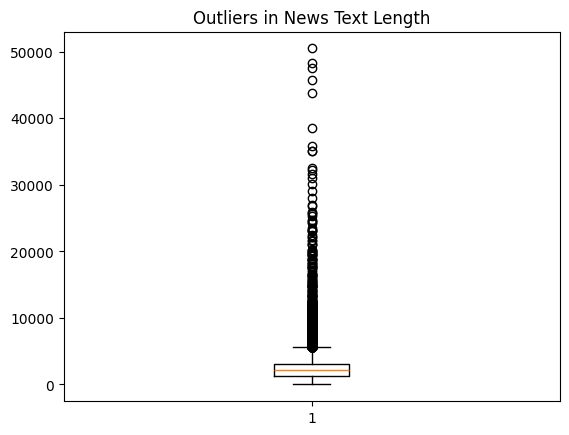

In [21]:
# 📈 Check outliers using boxplot

plt.boxplot(df["text_length"])
plt.title("Outliers in News Text Length")
plt.show()



In [22]:
# ❌ Remove extreme outliers (very short or very long news)
df = df[(df["text_length"] > 50) & (df["text_length"] < 10000)]



# 👀Display the Cleaned Data

In [23]:
# 👀 Show cleaned dataset
df.head()

,text,label,text_length
0,harare reuters zimbabwe s military seized pow...,1,7452
1,new york reuters a former aide to chris chris...,1,2906
2,apparently it takes just one american student ...,0,1269
3,moscow reuters russia’s foreign ministry said...,1,461
4,amsterdam reuters bosnian croat war crimes co...,1,1179


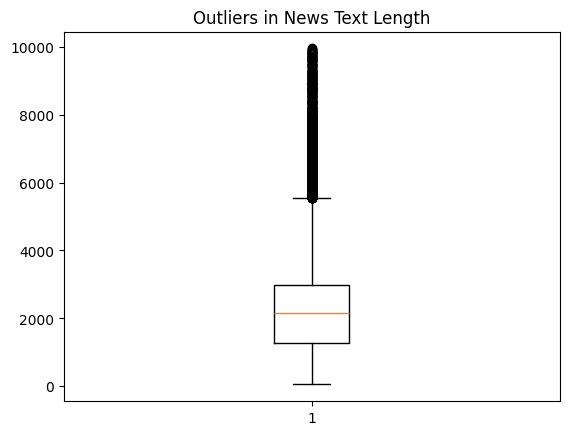

In [24]:

# 📈 Check outliers using boxplot

plt.boxplot(df["text_length"])
plt.title("Outliers in News Text Length")
plt.show()



# **📊 EXPLORATORY DATA ANALYSIS (EDA)**






# 📏 Check Dataset Shape

In [25]:
# 📏 Check number of rows and columns
df.shape

(38305, 3)

# ℹ️ View Dataset Information

In [26]:
# ℹ️ Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38305 entries, 0 to 38646
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         38305 non-null  object
 1   label        38305 non-null  int64 
 2   text_length  38305 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ MB


# 📊 Statistical Summary

In [27]:
# 📊 Summary statistics
df.describe()

,label,text_length
count,38305.000000,38305.000000
mean,0.552695,2323.695836
std,0.497222,1485.101837
min,0.000000,51.000000
25%,0.000000,1286.000000
50%,1.000000,2164.000000
75%,1.000000,2992.000000
max,1.000000,9954.000000


# 📰 Check Fake vs Real News Count

In [28]:
# 📊 Count fake and real news
df["label"].value_counts()


label
1    21171
0    17134
Name: count, dtype: int64

# 📉 Visualize News Distribution

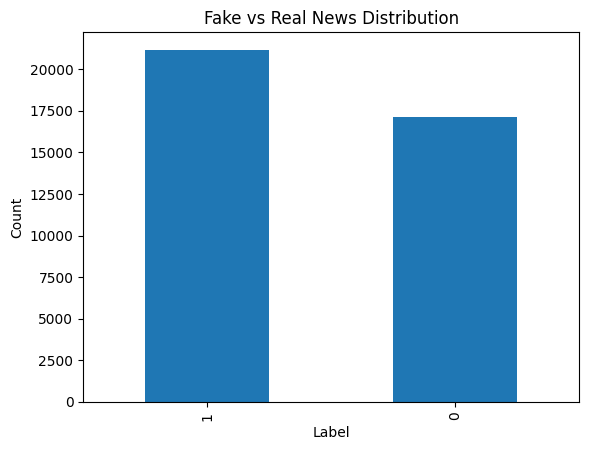

In [29]:
import matplotlib.pyplot as plt

# 📊 Bar chart of fake vs real news
df["label"].value_counts().plot(kind="bar")

plt.title("Fake vs Real News Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()


# 📈 Text Length Distribution

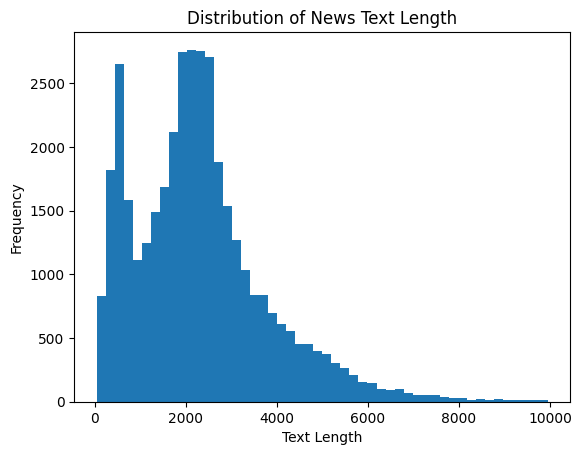

In [30]:
# 📈 Histogram of text length
plt.hist(df["text_length"], bins=50)

plt.title("Distribution of News Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")

plt.show()

# 📦 Outliers Visualization (Boxplot)

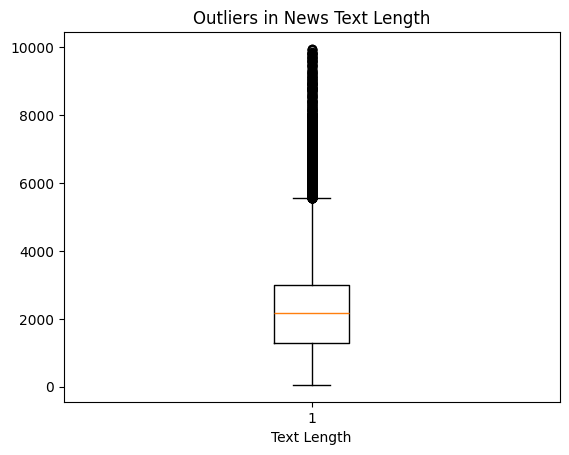

In [31]:
# 📦 Boxplot to visualize outliers in text length

import matplotlib.pyplot as plt

plt.boxplot(df["text_length"])

plt.title("Outliers in News Text Length")
plt.xlabel("Text Length")

plt.show()

# 🧠 Most Common Words in News

In [32]:
from collections import Counter

# 🧠 Combine all text
all_words = " ".join(df["text"]).split()

# 🔢 Count most common words
common_words = Counter(all_words).most_common(10)

common_words

[('the', 824365),
 ('to', 444420),
 ('of', 358825),
 ('a', 340793),
 ('and', 331736),
 ('in', 287259),
 ('that', 194860),
 ('on', 163014),
 ('for', 142799),
 ('s', 139189)]

# MODEL SELECTION AND TRAINING 

## 🧹 Text Preprocessing

Before training a deep learning model, the news text needs to be cleaned.

Text preprocessing helps improve model performance by removing noise.

### The following operations are performed:
- 🔤 Convert text to lowercase
- ❌ Remove punctuation
- 🔢 Remove numbers
- 🧹 Remove extra spaces

This ensures the model focuses only on meaningful textual patterns.

In [33]:
import re

# 🧹 Function to clean text
def clean_text(text):

    # convert to lowercase
    text = text.lower()
    
    # remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # remove numbers
    text = re.sub(r'\d+', '', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# ✨ Apply cleaning function
df["clean_text"] = df["text"].apply(clean_text)

# 👀 Preview cleaned text
df[["text","clean_text"]].head()

,text,clean_text
0,harare reuters zimbabwe s military seized pow...,harare reuters zimbabwe s military seized powe...
1,new york reuters a former aide to chris chris...,new york reuters a former aide to chris christ...
2,apparently it takes just one american student ...,apparently it takes just one american student ...
3,moscow reuters russia’s foreign ministry said...,moscow reuters russias foreign ministry said o...
4,amsterdam reuters bosnian croat war crimes co...,amsterdam reuters bosnian croat war crimes con...


## Train Test Split  
### 📂 Splitting Dataset

To evaluate the model properly, the dataset is divided into:

- 📚 **Training Set (80%)** → used to train the model
- 🧪 **Testing Set (20%)** → used to evaluate the model

This helps check how well the model generalizes to unseen data.

In [34]:
from sklearn.model_selection import train_test_split

# 📥 Features and Labels
X = df["clean_text"]
y = df["label"]

# ✂️ Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 30644
Testing Samples: 7661


## 🔤 Tokenization

Deep learning models cannot understand raw text.

Therefore, text must be converted into **numerical sequences**.

### Steps:
1️⃣ Build a vocabulary of words  
2️⃣ Convert words → numbers  
3️⃣ Pad sequences so all inputs have equal length

In [35]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 📚 Define vocabulary size
vocab_size = 10000

# 🔤 Create tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")

# 🧠 Fit tokenizer on training text
tokenizer.fit_on_texts(X_train)

# 🔢 Convert text → sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 📏 Define maximum length
max_length = 300

# 📦 Padding sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding="post")

print("Padded training shape:", X_train_pad.shape)

Padded training shape: (30644, 300)


# 🧠 Deep Learning Model Selection

For fake news detection, **LSTM (Long Short-Term Memory)** networks are commonly used.

Why LSTM?

✔ Captures long-term dependencies in text  
✔ Works well for NLP tasks  
✔ Handles sequential data efficiently  

### Model Architecture
- 🔤 Embedding Layer
- 🔁 LSTM Layer
- 🎯 Dense Output Layer

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# 🧠 Build the model
model = Sequential()

# 🔤 Embedding layer
model.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length))

# 🔁 LSTM layer
model.add(LSTM(64))

# 💧 Dropout to prevent overfitting
model.add(Dropout(0.5))

# 🎯 Output layer
model.add(Dense(1, activation="sigmoid"))

# 📊 Compile model
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# 👀 Model summary
model.summary()

C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 🚀 Model Training

The model is trained using the padded training sequences.

### Training Parameters
- Epochs → number of training cycles
- Batch Size → number of samples per training step

The model learns patterns that distinguish **Fake News from Real News**.

In [37]:
# 🚀 Train model

history = model.fit(

    X_train_pad,
    y_train,
    
    epochs=5,
    batch_size=64,
    
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
479/479 ━━━━━━━━━━━━━━━━━━━━ 114s 227ms/step - accuracy: 0.8186 - loss: 0.3973 - val_accuracy: 0.8426 - val_loss: 0.3158
Epoch 2/5
479/479 ━━━━━━━━━━━━━━━━━━━━ 100s 209ms/step - accuracy: 0.8964 - loss: 0.2259 - val_accuracy: 0.9667 - val_loss: 0.1208
Epoch 3/5
479/479 ━━━━━━━━━━━━━━━━━━━━ 110s 230ms/step - accuracy: 0.9216 - loss: 0.2402 - val_accuracy: 0.9662 - val_loss: 0.1178
Epoch 4/5
479/479 ━━━━━━━━━━━━━━━━━━━━ 101s 211ms/step - accuracy: 0.9794 - loss: 0.0848 - val_accuracy: 0.9642 - val_loss: 0.1321
Epoch 5/5
479/479 ━━━━━━━━━━━━━━━━━━━━ 94s 195ms/step - accuracy: 0.9843 - loss: 0.0647 - val_accuracy: 0.9714 - val_loss: 0.1049


## 📊 Model Evaluation

After training, the model is evaluated on the **test dataset**.

This shows how well the model performs on unseen data.

Metrics used:
- 🎯 Accuracy
- ❌ Loss

In [38]:
# 📊 Evaluate model

loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.9714 - loss: 0.1049
Test Loss: 0.10492057353258133
Test Accuracy: 0.9714136719703674


## 📈 Training Performance Visualization

We plot the training and validation accuracy to observe:

- 📊 Model learning behaviour
- 📉 Overfitting or underfitting

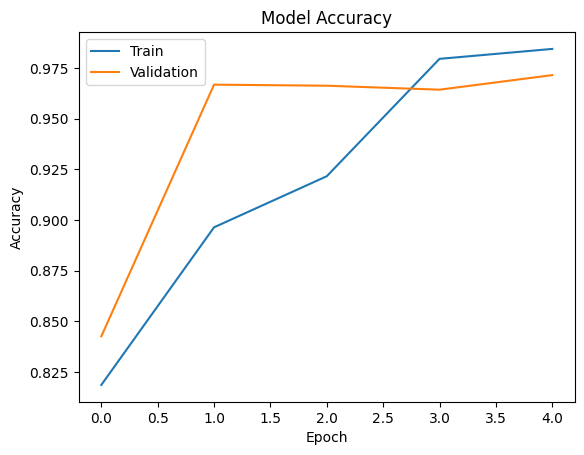

In [39]:
import matplotlib.pyplot as plt

# 📈 Plot accuracy
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

## 🔎 Fake News Prediction

The trained model can now predict whether a news article is:

📰 **Real News (0)**  
🚨 **Fake News (1)**

In [40]:
# 🔎 Example prediction

sample_news = ["Breaking: Government announces new economic reforms today"]

# preprocess
sample_seq = tokenizer.texts_to_sequences(sample_news)
sample_pad = pad_sequences(sample_seq, maxlen=max_length)

# predict
prediction = model.predict(sample_pad)

print("Prediction Score:", prediction)

if prediction > 0.5:
    print("🚨 Fake News")
else:
    print("📰 Real News")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
Prediction Score: [[0.50688756]]
🚨 Fake News


# MODEL EVALUATION AND HYPERPARAMETER TUNING

## 📊 Model Evaluation

After training the model, we evaluate its performance using several metrics.

While **accuracy** gives an overall idea of model performance, it is not always sufficient for classification tasks.

Therefore we also use:

- 📈 Precision
- 🔍 Recall
- ⚖️ F1 Score
- 📉 Confusion Matrix

These metrics help us better understand how well the model distinguishes **Fake News from Real News**.

In [41]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import numpy as np

# 🔎 Predict probabilities
y_pred_prob = model.predict(X_test_pad)

# 🔢 Convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype(int)

# 📊 Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

240/240 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      3462
           1       0.97      0.98      0.97      4199

    accuracy                           0.97      7661
   macro avg       0.97      0.97      0.97      7661
weighted avg       0.97      0.97      0.97      7661



## 📉 Confusion Matrix

A confusion matrix helps visualize model predictions.

It shows:

- True Positives ✔
- True Negatives ✔
- False Positives ❌
- False Negatives ❌

This allows us to see where the model is making mistakes.

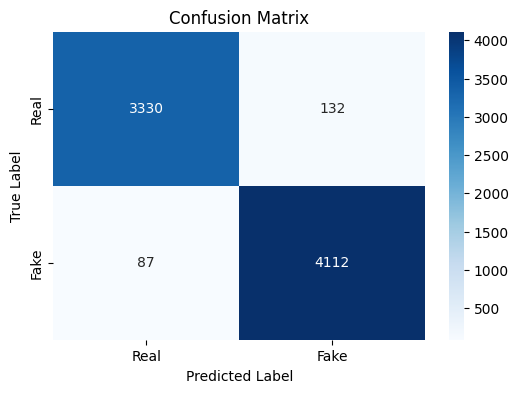

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# 📉 Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 🎨 Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real","Fake"],
    yticklabels=["Real","Fake"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## ⚙️ Hyperparameter Tuning

Hyperparameters are configuration settings used to control how a model learns.

Some important hyperparameters include:

- 🔤 Vocabulary Size
- 📏 Sequence Length
- 🧠 LSTM Units
- 📉 Dropout Rate
- 📦 Batch Size
- 🔁 Number of Epochs

By adjusting these parameters, we can improve model performance.

## 🔁 Hyperparameter Experimentation

In this step we modify key parameters of the neural network:

- Increase LSTM units
- Adjust dropout rate
- Change embedding dimension

These experiments help determine the best configuration for detecting fake news.

In [43]:
from tensorflow.keras.layers import Bidirectional

# 🧠 Improved model with tuned parameters
tuned_model = Sequential()

# 🔤 Embedding layer
tuned_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_length=max_length
))

# 🔁 Bidirectional LSTM
tuned_model.add(Bidirectional(LSTM(128)))

# 💧 Dropout
tuned_model.add(Dropout(0.4))

# 🎯 Output layer
tuned_model.add(Dense(1, activation="sigmoid"))

# ⚙️ Compile model
tuned_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 👀 Model summary
tuned_model.summary()

C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 🚀 Training the Tuned Model

After adjusting the hyperparameters, the tuned model is trained again.

The goal is to determine whether the new configuration improves performance compared to the original model.

In [44]:
tuned_history = tuned_model.fit(

    X_train_pad,
    y_train,

    epochs=7,
    batch_size=32,

    validation_data=(X_test_pad, y_test)
)

Epoch 1/7
958/958 ━━━━━━━━━━━━━━━━━━━━ 546s 562ms/step - accuracy: 0.9496 - loss: 0.1259 - val_accuracy: 0.9719 - val_loss: 0.0822
Epoch 2/7
958/958 ━━━━━━━━━━━━━━━━━━━━ 525s 548ms/step - accuracy: 0.9806 - loss: 0.0524 - val_accuracy: 0.9832 - val_loss: 0.0534
Epoch 3/7
958/958 ━━━━━━━━━━━━━━━━━━━━ 552s 576ms/step - accuracy: 0.9891 - loss: 0.0300 - val_accuracy: 0.9721 - val_loss: 0.0788
Epoch 4/7
958/958 ━━━━━━━━━━━━━━━━━━━━ 527s 550ms/step - accuracy: 0.9965 - loss: 0.0108 - val_accuracy: 0.9883 - val_loss: 0.0426
Epoch 5/7
958/958 ━━━━━━━━━━━━━━━━━━━━ 566s 591ms/step - accuracy: 0.9985 - loss: 0.0054 - val_accuracy: 0.9886 - val_loss: 0.0413
Epoch 6/7
958/958 ━━━━━━━━━━━━━━━━━━━━ 594s 561ms/step - accuracy: 0.9989 - loss: 0.0036 - val_accuracy: 0.9890 - val_loss: 0.0538
Epoch 7/7
958/958 ━━━━━━━━━━━━━━━━━━━━ 547s 571ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 0.9890 - val_loss: 0.0512


## 📈 Performance Comparison

We compare the performance of:

- Original Model
- Tuned Model

This helps determine whether hyperparameter tuning improved the model.

In [45]:
# 📊 Evaluate tuned model
loss, accuracy = tuned_model.evaluate(X_test_pad, y_test)

print("Tuned Model Loss:", loss)
print("Tuned Model Accuracy:", accuracy)

240/240 ━━━━━━━━━━━━━━━━━━━━ 38s 159ms/step - accuracy: 0.9890 - loss: 0.0512
Tuned Model Loss: 0.051201172173023224
Tuned Model Accuracy: 0.9890353679656982


## 📊 Training vs Validation Accuracy

Plotting accuracy helps visualize:

- Model learning progress
- Overfitting behavior
- Performance improvement after tuning

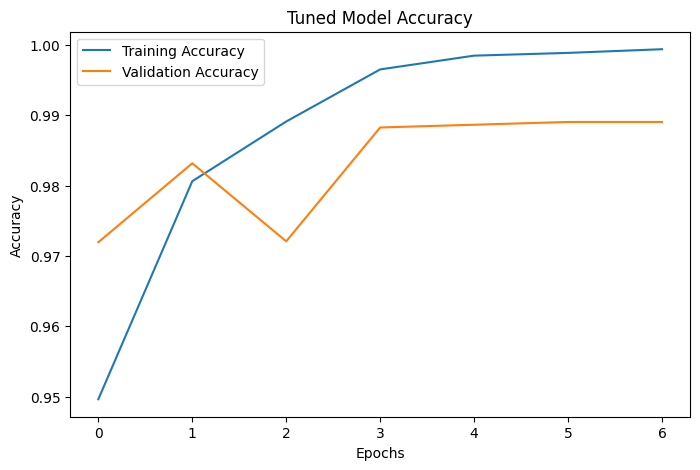

In [46]:
plt.figure(figsize=(8,5))

plt.plot(tuned_history.history['accuracy'])
plt.plot(tuned_history.history['val_accuracy'])

plt.title("Tuned Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend(["Training Accuracy","Validation Accuracy"])

plt.show()

## 🎯 Final Prediction System - Final Fake News Detection System

The trained model can now classify any news article as:

📰 Real News  
🚨 Fake News

This completes the Fake News Detection pipeline.

In [47]:
def predict_news(news):

    # clean text
    news = clean_text(news)

    # tokenize
    seq = tokenizer.texts_to_sequences([news])

    # pad
    pad = pad_sequences(seq, maxlen=max_length)

    # predict
    prediction = tuned_model.predict(pad)

    if prediction > 0.5:
        return "🚨 Fake News"
    else:
        return "📰 Real News"


# Example
predict_news("Scientists discovered new technology to generate unlimited clean energy.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


'📰 Real News'

In [49]:
import pickle

# 1. Save the Keras model (since you used deep learning/LSTM)
tuned_model.save('model_files/truthlens_model.h5')

# 2. Save the tokenizer (this is crucial to keep text-to-number mapping consistent)
with open('model_files/tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# 3. Save the max_length variable so the backend knows the padding size
with open('model_files/config.pkl', 'wb') as f:
    pickle.dump({'max_length': max_length}, f)

print("All TruthLens assets exported successfully!")

All TruthLens assets exported successfully!
